In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [56]:
tornados_outage_2023 = pd.read_csv('../merged/tornados_outage_2023.csv', parse_dates=['DATE'])



In [57]:
tornados_outage_2023.head()

,Unnamed: 0,DATE,AVGDV_max,LLDV_max,MXDV_max,MXDV_HEIGHT_max,DEPTH_max,MAX_SHEAR_max,MAX_SHEAR_HEIGHT_max,location,county,state,Event Month,power_outage
0,0,2023-01-01,36,49,56,7,6.5,29,6.6,"(32.39305, -110.68147)",Pima County,Arizona,NaN,False
1,1,2023-01-01,52,96,96,2,5.9,86,1.8,"(32.18141, -110.52664)",Cochise County,Arizona,NaN,False
2,2,2023-01-01,31,50,50,4,9.1,17,4.2,"(34.34357, -117.82177)",San Bernardino County,California,NaN,False
3,3,2023-01-01,35,62,62,6,8.3,21,6.4,"(34.29869, -117.62836)",San Bernardino County,California,NaN,False
4,4,2023-01-01,39,52,52,4,5.0,24,2.6,"(35.0269, -118.24596)",Kern County,California,NaN,False


In [58]:
tornados_outage_2023['DATE'] = pd.to_datetime(tornados_outage_2023['DATE'])
tornados_outage_2023['Month'] = tornados_outage_2023['DATE'].dt.month

In [59]:
tornados_outage_2023.sample(5)

,Unnamed: 0,DATE,AVGDV_max,LLDV_max,MXDV_max,MXDV_HEIGHT_max,DEPTH_max,MAX_SHEAR_max,MAX_SHEAR_HEIGHT_max,location,county,state,Event Month,power_outage,Month
21471,21471,2023-06-25,30,52,67,27,24.6,23,27.3,"(41.5294, -88.71646)",LaSalle County,Illinois,NaN,False,6
1508,1508,2023-01-25,25,49,49,4,21.9,17,3.8,"(33.447, -77.80629)",Brunswick County,North Carolina,January,False,1
20260,20260,2023-06-20,57,95,132,32,29.1,46,31.9,"(30.34883619047619, -89.74697952380953)",Saint Tammany Parish,Louisiana,NaN,False,6
11882,11882,2023-04-21,47,85,93,24,22.3,35,24.2,"(29.32458, -95.716)",Fort Bend County,Texas,NaN,False,4
6367,6367,2023-03-03,63,99,99,11,19.8,36,10.8,"(38.36749, -86.462355)",Crawford County,Indiana,March,False,3


In [60]:
print(tornados_outage_2023['location'].dtype)

object


In [61]:
tornados_outage_2023[['Latitude', 'Longitude']] = tornados_outage_2023['location'].apply(lambda x: pd.Series(str(x).strip('()').split(',')))


In [62]:
tornados_outage_2023.sample(5)

,Unnamed: 0,DATE,AVGDV_max,LLDV_max,MXDV_max,MXDV_HEIGHT_max,DEPTH_max,MAX_SHEAR_max,MAX_SHEAR_HEIGHT_max,location,county,state,Event Month,power_outage,Month,Latitude,Longitude
27295,27295,2023-07-25,31,58,58,5,11.0,17,4.8,"(39.021055, -104.067205)",El Paso County,Colorado,NaN,False,7,39.021055,-104.067205
21715,21715,2023-06-26,31,52,60,6,23.0,22,5.5,"(34.53868, -88.7594)",Lee County,Mississippi,NaN,False,6,34.53868,-88.7594
26560,26560,2023-07-21,42,23,73,5,7.3,33,4.5,"(35.3618, -90.42227)",Crittenden County,Arkansas,NaN,False,7,35.3618,-90.42227
35869,35869,2023-09-19,55,75,75,3,7.3,36,2.5,"(34.96672, -96.95512)",Garvin County,Oklahoma,NaN,False,9,34.96672,-96.95512
15091,15091,2023-05-23,43,83,85,7,24.9,43,7.0,"(26.65321, -80.24385)",Palm Beach County,Florida,NaN,False,5,26.65321,-80.24385


In [63]:
from sklearn.model_selection import train_test_split

In [101]:
tornados_train, tornados_test = train_test_split(tornados_outage_2023.copy(),
                                              shuffle=True,
                                              random_state=123,
                                              test_size=.1,
                                              stratify=tornados_outage_2023.power_outage.values)

In [102]:
tornados_tt, tornados_val = train_test_split(tornados_train.copy(),
                                              shuffle=True,
                                              random_state=123,
                                              test_size=.1,
                                              stratify=tornados_train.power_outage.values)

In [103]:
tornados_grouped_by = tornados_tt.groupby(['power_outage'])
tornados_balanced = tornados_grouped_by.apply(lambda x: x.sample(tornados_grouped_by.size().min()).reset_index(drop=True))
tornados_btt =tornados_balanced.droplevel(['power_outage'])

In [67]:
## import random forest classifier
from sklearn.ensemble import RandomForestClassifier

## import kfold
from sklearn.model_selection import StratifiedKFold

## import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score



In [68]:
#def powerset(s):
#    power_set = [[]]
#    for x in s:
#        power_set += [s0+[x] for s0 in power_set]
#    return power_set[1:]

In [69]:
#potential_features = ['AVGDV_max', 'LLDV_max', 'MXDV_max', 'MXDV_HEIGHT_max', 'DEPTH_max',
#      'MAX_SHEAR_max', 'MAX_SHEAR_HEIGHT_max', 'state']

#all_models = ['baseline']
#all_models.extend(powerset(potential_features))

In [70]:
## this will isolate the feature columns
features = ['AVGDV_max', 'LLDV_max', 'MXDV_max', 'MXDV_HEIGHT_max', 'DEPTH_max',
       'MAX_SHEAR_max', 'MAX_SHEAR_HEIGHT_max', 'Month', 'Latitude', 'Longitude' ]

In [71]:

features

['AVGDV_max',
 'LLDV_max',
 'MXDV_max',
 'MXDV_HEIGHT_max',
 'DEPTH_max',
 'MAX_SHEAR_max',
 'MAX_SHEAR_HEIGHT_max',
 'Month',
 'Latitude',
 'Longitude']

In [72]:
## set the number of CV folds
n_splits = 5

## Make the kfold object
kfold = StratifiedKFold(n_splits, 
                        random_state=216, 
                        shuffle=True)

In [73]:
max_depths = range(1, 11)
n_trees = [100, 500]

#rf_accs = np.zeros((n_splits, len(max_depths), len(n_trees)))



#for i,(train_index, test_index) in enumerate(kfold.split(tornados_train, tornados_train.power_outage)):
#    tornados_tt = tornados_train.iloc[train_index]
#   tornados_ho = tornados_train.iloc[test_index]

#    for j, max_depth in enumerate(max_depths):
#       for k, n_estimators in enumerate(n_trees):
#            print(i,j,k)
#            rf = RandomForestClassifier(n_estimators = n_estimators,
#                                           max_depth = max_depth,
#                                           max_samples = 0.8,
#                                           random_state = 216)
#                                          
#            rf.fit(tornados_tt[features], tornados_tt.power_outage)
#            
#            pred = rf.predict(tornados_ho[features])
#            
#            rf_accs[i,j,k] = accuracy_score(tornados_ho.power_outage,  pred)

In [74]:
#max_depths = range(1, 11)
#n_trees = [100, 500]

#rf_accs = np.zeros((n_splits, len(max_depths), len(n_trees)))
#rf_prec = np.zeros((n_splits, len(max_depths), len(n_trees)))
#rf_recall = np.zeros((n_splits, len(max_depths), len(n_trees)))



#for i,(train_index, test_index) in enumerate(kfold.split(tornados_train, tornados_train.power_outage)):
#    tornados_tt = tornados_train.iloc[train_index]
#    tornados_ho = tornados_train.iloc[test_index]

#    for j, max_depth in enumerate(max_depths):
#        for k, n_estimators in enumerate(n_trees):
#            print(i,j,k)
#            rf = RandomForestClassifier(n_estimators = n_estimators,
#                                           max_depth = max_depth,
#                                           max_samples = 0.8,
#                                           random_state = 216)
#                                           
#            rf.fit(tornados_tt[features], tornados_tt.power_outage)
#            
#            pred = rf.predict(tornados_ho[features])
#            
#            rf_accs[i,j,k] = accuracy_score(tornados_ho.power_outage,  pred)
#            rf_prec[i,j,k]= precision_score(tornados_ho.power_outage,  pred)
#            rf_recall[i,j,k]= recall_score(tornados_ho.power_outage,  pred)

We will do `GridSearchCV

In [75]:
max_index_prec = np.unravel_index(np.argmax(np.mean(rf_prec, axis=0)), 
                                       np.mean(rf_prec, axis=0).shape)


print(max_depths[max_index_prec[0]],n_trees[max_index_prec[1]])

10 500


In [76]:
max_index_recall = np.unravel_index(np.argmax(np.mean(rf_recall, axis=0)), 
                                       np.mean(rf_recall, axis=0).shape)


print(max_depths[max_index_recall[0]],n_trees[max_index_recall[1]])

4 100


In [77]:
np.mean(rf_recall, axis=0)

array([[0.9758222 , 0.9712245 ],
       [0.9758222 , 0.97697163],
       [0.98273204, 0.98733639],
       [0.99079131, 0.99079131],
       [0.99079131, 0.98734303],
       [0.98849246, 0.98734303],
       [0.98734303, 0.98734303],
       [0.98849246, 0.98734303],
       [0.98619361, 0.98504418],
       [0.98157598, 0.98273204]])

In [78]:
np.mean(rf_prec, axis=0)

array([[0.78547553, 0.78535544],
       [0.78679888, 0.78634786],
       [0.80072113, 0.79991762],
       [0.80188987, 0.80188153],
       [0.80480108, 0.80203305],
       [0.80663123, 0.80729852],
       [0.80808991, 0.80954017],
       [0.81562458, 0.81266139],
       [0.8157138 , 0.82012749],
       [0.82046309, 0.82538019]])

In [79]:
max_index = np.unravel_index(np.argmax(np.mean(rf_accs, axis=0)), 
                                       np.mean(rf_accs, axis=0).shape)


print(max_depths[max_index[0]],n_trees[max_index[1]])

10 500


In [80]:
## first import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [81]:
grid_cv = GridSearchCV(RandomForestClassifier(), # first put the model object here
                          param_grid = {'max_depth':max_depths, # place the grid values for max_depth and
                                        'n_estimators':n_trees}, # and n_estimators here
                          scoring = 'accuracy', # put the metric we are trying to optimize here as a string, "accuracy"
                          cv = 5) # put the number of cv splits here

## you fit it just like a model
grid_cv.fit(tornados_train[features], tornados_train.power_outage)

KeyboardInterrupt: 

In [ ]:
## You can find the hyperparameter grid point that
## gave the best performance like so
## .best_params_
grid_cv.best_params_

{'max_depth': 10, 'n_estimators': 500}

In [ ]:
## You can find the best score like so
## .best_score_
grid_cv.best_score_

0.8917685249594223

In [ ]:
## Calling best_estimator_ returns the model with the 
## best avg cv performance after it has been refit on the
## entire data set
grid_cv.best_estimator_

RandomForestClassifier(max_depth=10, n_estimators=500)

In [ ]:
#grid_cv.best_estimator_.predict(tornados_train[features])
#model= RandomForestClassifier(n_estimators=500, max_depth=10)
#model.fit(tornados_train[features], tornados_train.power_outage)


In [ ]:
## You can get all of the results with cv_results_
grid_cv.cv_results_

{'mean_fit_time': array([0.18038411, 0.79723034, 0.234372  , 0.88442307, 0.20888991,
        1.17788391, 0.26650958, 1.2890388 , 0.27242079, 1.37710047,
        0.33602457, 1.62179441, 0.38315759, 1.96872973, 0.36948252,
        2.04286451, 0.4389998 , 2.1678195 , 0.62587967, 2.44551406]),
 'std_fit_time': array([0.04105907, 0.06378292, 0.03165184, 0.02781905, 0.00399288,
        0.0953091 , 0.01830444, 0.0795501 , 0.00858043, 0.05561575,
        0.03596788, 0.06742709, 0.01908316, 0.29239047, 0.01165248,
        0.3740278 , 0.04931235, 0.29503778, 0.04624427, 0.10141383]),
 'mean_score_time': array([0.0127255 , 0.05764251, 0.01273007, 0.04525366, 0.01109748,
        0.0512156 , 0.01192904, 0.04924827, 0.01164122, 0.04899716,
        0.01370091, 0.05814304, 0.01540751, 0.05510454, 0.0136342 ,
        0.06054001, 0.01382465, 0.06726737, 0.02104783, 0.06872435]),
 'std_score_time': array([0.00365462, 0.00920197, 0.00205953, 0.00366017, 0.00220452,
        0.00785274, 0.00196835, 0.002054

Using either the `best_estimator_` fitted model or a refitted model according to our results from the `for` loop cross-validation we will find the feature importance scores. 

In [ ]:
pd.DataFrame({'feature_importance_score':grid_cv.best_estimator_.feature_importances_},
                 index=features).sort_values('feature_importance_score',
                                                ascending=False)

,feature_importance_score
Month,0.553668
Longitude,0.151348
Latitude,0.118890
DEPTH_max,0.031267
MAX_SHEAR_max,0.030051
MXDV_max,0.028836
AVGDV_max,0.027080
LLDV_max,0.024210
MAX_SHEAR_HEIGHT_max,0.021146
MXDV_HEIGHT_max,0.013504


Bagging

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate

In [84]:
pipe = Pipeline([('scale', StandardScaler()),('knn',KNeighborsClassifier())])
bag_pipe = BaggingClassifier(pipe, bootstrap = True, max_samples = 0.90)
bag_cv = GridSearchCV(bag_pipe, 
                          param_grid = {'estimator__knn__n_neighbors':[1,2,3], 
                                        'n_estimators':np.arange(1,100,10)}, 
                          scoring = 'accuracy', 
                          cv = 5)
bag_cv.fit(tornados_btt[features], tornados_btt.power_outage)

GridSearchCV(cv=5,
             estimator=BaggingClassifier(estimator=Pipeline(steps=[('scale',
                                                                    StandardScaler()),
                                                                   ('knn',
                                                                    KNeighborsClassifier())]),
                                         max_samples=0.9),
             param_grid={'estimator__knn__n_neighbors': [1, 2, 3],
                         'n_estimators': array([ 1, 11, 21, 31, 41, 51, 61, 71, 81, 91])},
             scoring='accuracy')

In [85]:
print(f"The best mean cv accuracy of {bag_cv.best_score_:.3f} was achieved using k = {bag_cv.best_estimator_.estimator['knn'].n_neighbors} and {bag_cv.best_estimator_.n_estimators} estimators")

The best mean cv accuracy of 0.843 was achieved using k = 3 and 51 estimators


In [86]:
single_pipe = Pipeline([('scale', StandardScaler()),('knn',KNeighborsClassifier(n_neighbors=3))])
single_cv = cross_validate(single_pipe, tornados_train[features], tornados_train.power_outage, cv = 5, scoring = 'accuracy')

In [87]:
print(f"The mean cv accuracy of a single kNN model with k=3 is {single_cv['test_score'].mean():.3f}")

The mean cv accuracy of a single kNN model with k=3 is 0.842


Model with `GridSearchCV`

In [104]:
#model = grid_cv.best_estimator_
model=RandomForestClassifier(n_estimators=500, max_depth=10)
model.fit(tornados_btt[features], tornados_btt.power_outage)

RandomForestClassifier(max_depth=10, n_estimators=500)

In [105]:
accuracy_score(model.predict(tornados_val[features]), tornados_val.power_outage)

0.8119682359614294

In [106]:
accuracy_score(model.predict(tornados_test[features]), tornados_test.power_outage)

0.8042368555385401

In [107]:
prec_b= precision_score(model.predict(tornados_val[features]), tornados_val.power_outage)
print(prec_b)

0.9885057471264368


In [108]:
tornados_val.power_outage.value_counts()

power_outage
False    3439
True       87
Name: count, dtype: int64

In [109]:
rec_b=recall_score(model.predict(tornados_val[features]), tornados_val.power_outage)
print(rec_b)

0.11497326203208556


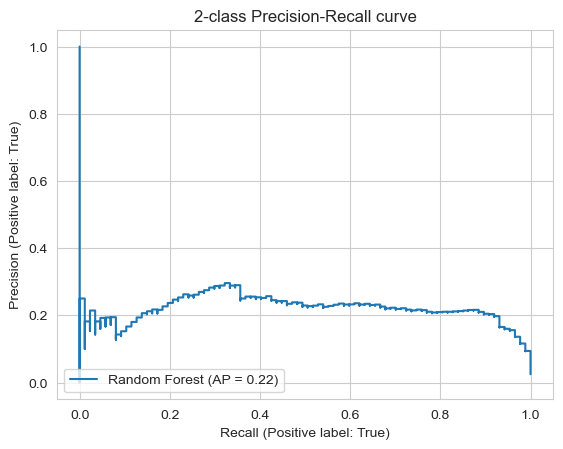

In [110]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_estimator(
model, tornados_val[features], tornados_val['power_outage'], name="Random Forest")
_= display.ax_.set_title("2-class Precision-Recall curve")

In [ ]:
accuracy_score(model.predict(tornados_outage_2023[features]), tornados_outage_2023.power_outage)

0.8128445987339187

In [ ]:
precision_score(model.predict(tornados_outage_2023[features]), tornados_outage_2023.power_outage)

0.9989637305699481

In [ ]:
recall_score(model.predict(tornados_outage_2023[features]), tornados_outage_2023.power_outage)

0.11621458710066306

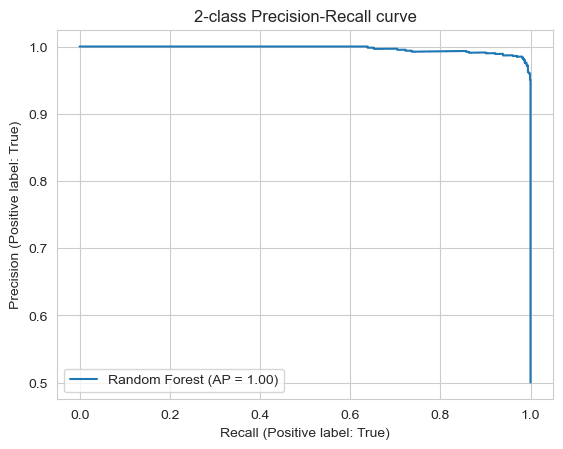

In [ ]:
display = PrecisionRecallDisplay.from_estimator(
model, tornados_train[features], tornados_train['power_outage'], name="Random Forest")
_= display.ax_.set_title("2-class Precision-Recall curve")

Now I'll do the training on the original data. 

In [ ]:
tornados_train, tornados_test = train_test_split(tornados_outage_2023.copy(),
                                              shuffle=True,
                                              random_state=123,
                                              test_size=.1,
                                              stratify=tornados_outage_2023.power_outage.values)

In [ ]:
features = ['AVGDV_max', 'LLDV_max', 'MXDV_max', 'MXDV_HEIGHT_max', 'DEPTH_max',
       'MAX_SHEAR_max', 'MAX_SHEAR_HEIGHT_max', 'Month', 'Latitude', 'Longitude' ]

In [ ]:
max_depths = range(1, 11)
n_trees = [100, 500]

In [ ]:
grid_cv = GridSearchCV(RandomForestClassifier(), # first put the model object here
                          param_grid = {'max_depth':max_depths, # place the grid values for max_depth and
                                        'n_estimators':n_trees}, # and n_estimators here
                          scoring = 'accuracy', # put the metric we are trying to optimize here as a string, "accuracy"
                          cv = 5) # put the number of cv splits here

## you fit it just like a model
grid_cv.fit(tornados_train[features], tornados_train.power_outage)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': range(1, 11), 'n_estimators': [100, 500]},
             scoring='accuracy')

In [ ]:
grid_cv.best_params_

{'max_depth': 10, 'n_estimators': 100}

In [ ]:
grid_cv.best_score_

0.9760621725853925

In [ ]:
grid_cv.best_estimator_

RandomForestClassifier(max_depth=10)

In [ ]:
grid_cv.best_estimator_.predict(tornados_train[features])

array([False, False, False, ..., False, False, False])

In [ ]:
grid_cv.cv_results_

{'mean_fit_time': array([ 0.72269893,  3.25753422,  1.09018965,  5.24724512,  1.56745925,
         8.09126325,  1.84145718,  9.84637136,  2.63361864, 10.76816907,
         2.53468599, 11.51865282,  2.48184228, 11.84761286,  2.6539299 ,
        13.00429549,  2.65894461, 13.75159726,  3.14884973, 18.60982013]),
 'std_fit_time': array([0.04667043, 0.10090216, 0.01553478, 0.07872414, 0.14043985,
        0.36402528, 0.21205456, 1.07612898, 0.32227203, 0.64867692,
        0.1789632 , 0.18920293, 0.18009893, 0.29922974, 0.31207005,
        0.50504928, 0.05951411, 0.51756946, 0.30953961, 1.15809032]),
 'mean_score_time': array([0.03446627, 0.13332872, 0.03663535, 0.14920158, 0.04303989,
        0.21358404, 0.05783725, 0.19897594, 0.05651293, 0.21828232,
        0.05554156, 0.22234912, 0.04907646, 0.2138885 , 0.05827913,
        0.23522511, 0.0517189 , 0.25149536, 0.06131592, 0.30580912]),
 'std_score_time': array([0.00115129, 0.00224493, 0.00087729, 0.00168361, 0.00185934,
        0.05165828, 

In [ ]:
pd.DataFrame({'feature_importance_score':grid_cv.best_estimator_.feature_importances_},
                 index=features).sort_values('feature_importance_score',
                                                ascending=False)

,feature_importance_score
Month,0.246133
Longitude,0.230353
Latitude,0.208172
DEPTH_max,0.056636
MAX_SHEAR_max,0.051384
MXDV_max,0.046850
MAX_SHEAR_HEIGHT_max,0.044120
LLDV_max,0.044120
AVGDV_max,0.041531
MXDV_HEIGHT_max,0.030702


In [ ]:
pipe = Pipeline([('scale', StandardScaler()),('knn',KNeighborsClassifier())])
bag_pipe = BaggingClassifier(pipe, bootstrap = True, max_samples = 0.90)
bag_cv = GridSearchCV(bag_pipe, 
                          param_grid = {'estimator__knn__n_neighbors':[1,2,3], 
                                        'n_estimators':np.arange(1,100,10)}, 
                          scoring = 'accuracy', 
                          cv = 5)
bag_cv.fit(tornados_train[features], tornados_train.power_outage)